In [3]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)

In [17]:
# Carregar pacote e dados
data(NelPlo)
# Extrair a série emp como ts
ts_data <- NelPlo[, "int.rate"]   # Note a vírgula e as aspas

dados_sem_na <- na.omit(as.numeric(ts_data))
novo_start <- start(ts_data) + c(0, (min(which(!is.na(ts_data)))-1) / frequency(ts_data))
ts_limpa <- ts(dados_sem_na, start = novo_start, frequency = frequency(ts_data))

ts_data <- ts_limpa

# Agora funciona
cat("Classe    :", class(ts_data), "\n")
cat("Início    :", start(ts_data), "\n")
cat("Fim       :", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "\n")
cat("N obs     :", length(ts_data), "\n")
print(summary(ts_data))

Classe    : ts 
Início    : 1900 1 


Fim       : 1988 1 
Frequência: 1 
N obs     : 89 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.430   3.300   4.100   4.916   5.100  13.229 


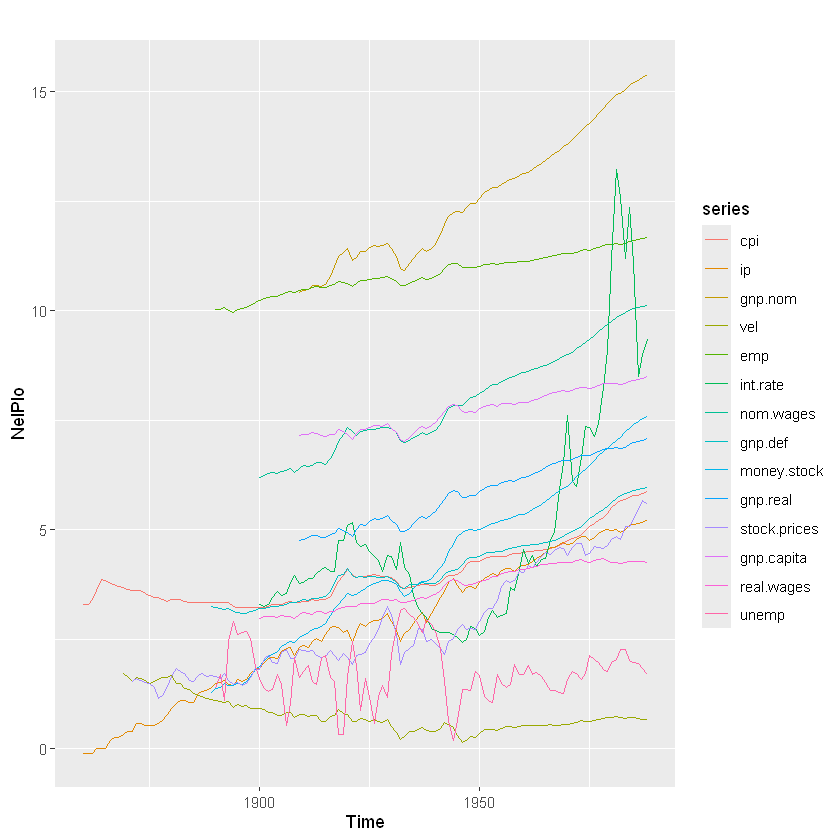

In [19]:
autoplot(NelPlo)

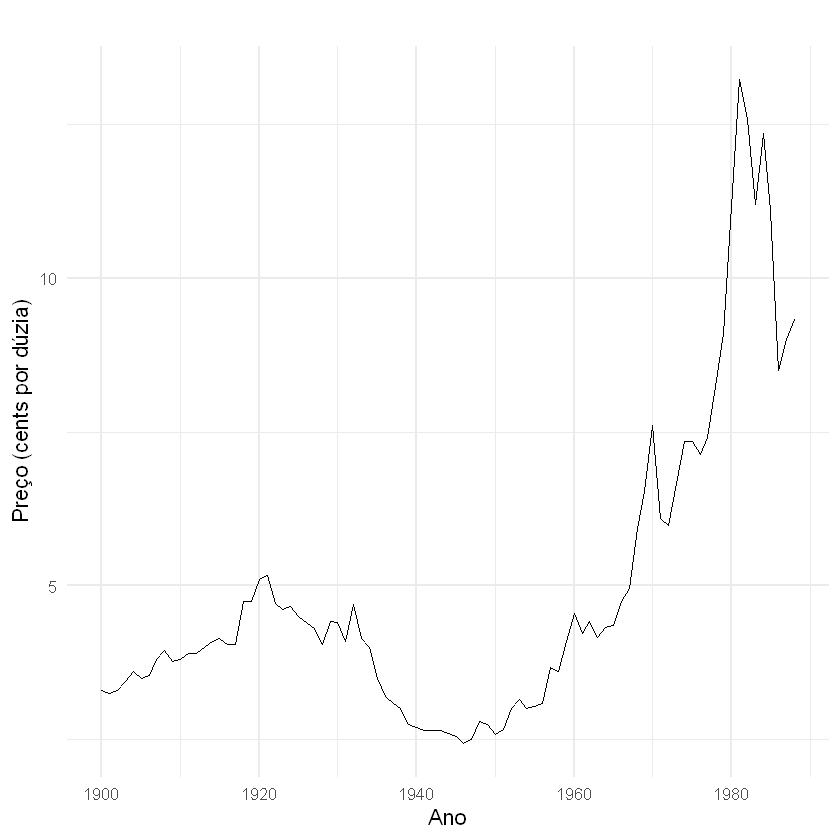

In [20]:
autoplot(ts_data) +
  labs(
    title = "",
    x     = "Ano",
    y     = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."


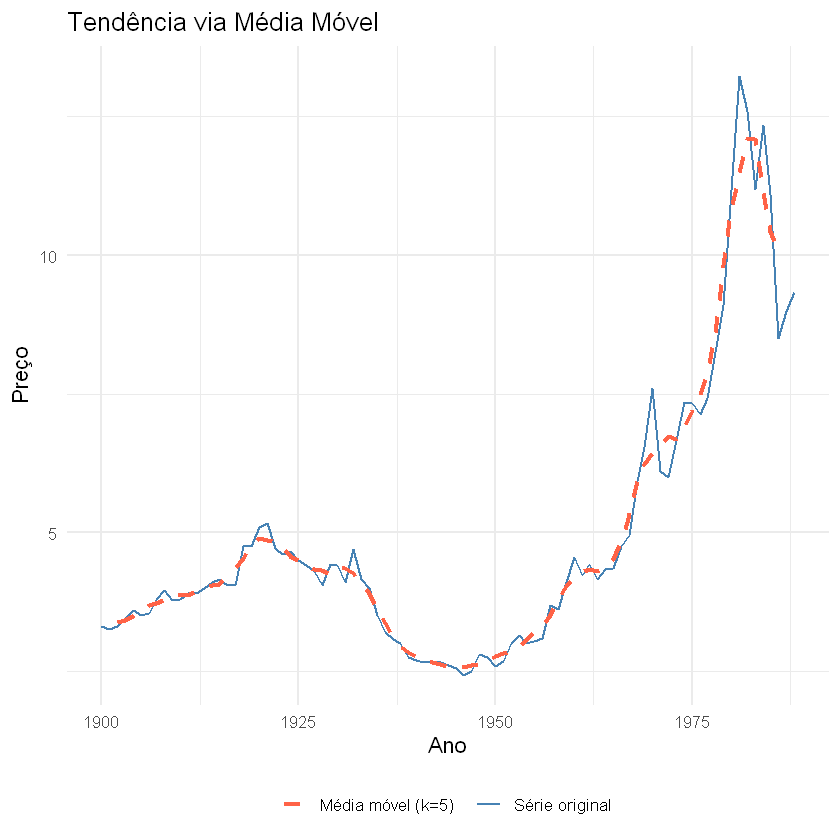

In [21]:
# Média móvel de ordem 5 para suavizar a tendência
library(zoo)
tendencia <- rollmean(ts_data, k = 5, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "steelblue", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

In [22]:
cat("=== Teste ADF — Série Original ===\n")
print(adf.test(ts_data))

=== Teste ADF — Série Original ===

	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -1.8103, Lag order = 4, p-value = 0.6541
alternative hypothesis: stationary



Diferenças aplicadas: 1 


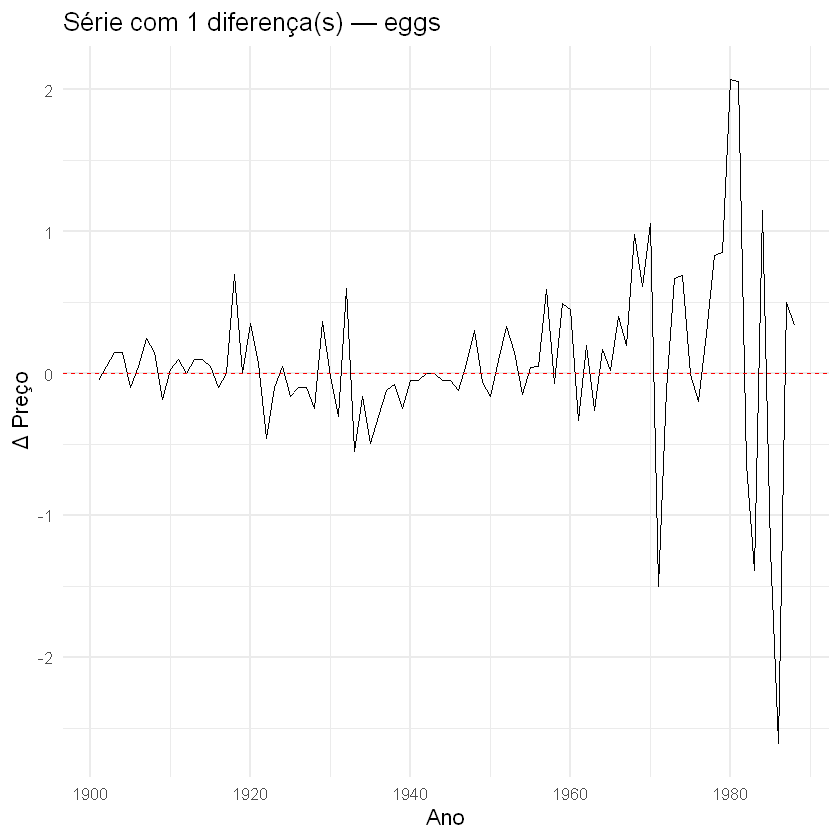

In [23]:
# Aplicando diferenciação simples
d <- ndiffs(ts_data)   # número de diferenças indicado

ts_diff <- ts_data
for (i in seq_len(d)) ts_diff <- diff(ts_diff)

cat("Diferenças aplicadas:", d, "\n")

autoplot(ts_diff) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = paste0("Série com ", d, " diferença(s) — eggs"),
    x = "Ano", y = "Δ Preço"
  ) +
  theme_minimal(base_size = 13)

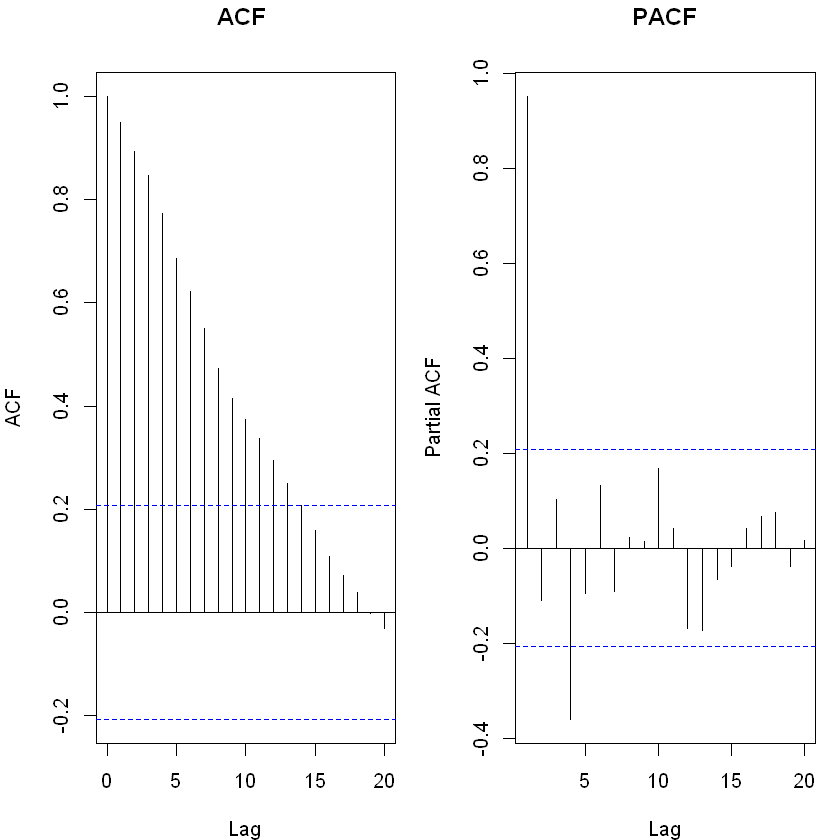

In [24]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_data,  lag.max = 20, main = "ACF ")
pacf(ts_data, lag.max = 20, main = "PACF")

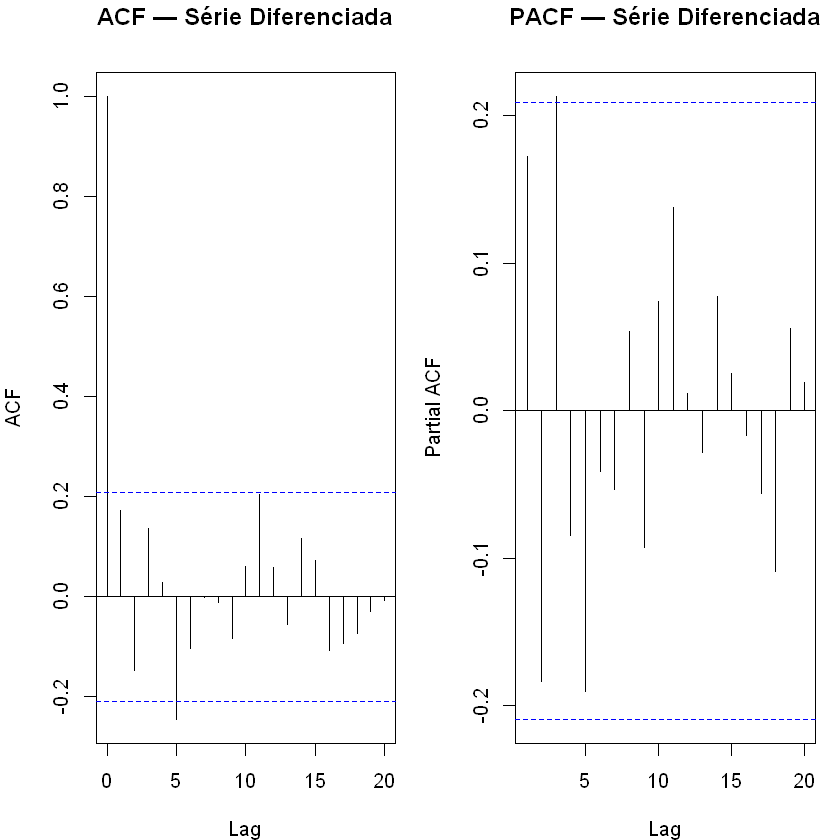

In [25]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_diff,  lag.max = 20, main = "ACF — Série Diferenciada")
pacf(ts_diff, lag.max = 20, main = "PACF — Série Diferenciada")

In [31]:
# Seleção automática
modelo_auto <- auto.arima(
  ts_data,
  stepwise      = FALSE,
  approximation = FALSE,
  trace         = TRUE
)

cat("\n=== Modelo selecionado automaticamente ===\n")
summary(modelo_auto)


 ARIMA(0,1,0)                    : 163.1479
 ARIMA(0,1,0) with drift         : 164.1005
 ARIMA(0,1,1)                    : 160.3285
 ARIMA(0,1,1) with drift         : 161.772
 ARIMA(0,1,2)                    : 159.6981
 ARIMA(0,1,2) with drift         : 160.9098
 ARIMA(0,1,3)                    : 161.5314
 ARIMA(0,1,3) with drift         : 162.9455
 ARIMA(0,1,4)                    : 160.5207
 ARIMA(0,1,4) with drift         : 162.4447
 ARIMA(0,1,5)                    : 158.8872
 ARIMA(0,1,5) with drift         : 160.1459
 ARIMA(1,1,0)                    : 162.2878
 ARIMA(1,1,0) with drift         : 163.6188
 ARIMA(1,1,1)                    : 160.1779
 ARIMA(1,1,1) with drift         : 161.5497
 ARIMA(1,1,2)                    : 161.8242
 ARIMA(1,1,2) with drift         : 163.1129
 ARIMA(1,1,3)                    : 163.4277
 ARIMA(1,1,3) with drift         : 165.0336
 ARIMA(1,1,4)                    : 160.9529
 ARIMA(1,1,4) with drift         : 162.8373
 ARIMA(2,1,0)                   

Series: ts_data 
ARIMA(5,1,0) 

Coefficients:
         ar1      ar2     ar3      ar4      ar5
      0.2585  -0.1964  0.2746  -0.0031  -0.2715
s.e.  0.1027   0.1061  0.1145   0.1200   0.1166

sigma^2 = 0.3153:  log likelihood = -71.94
AIC=155.89   AICc=156.92   BIC=170.75

Training set error measures:
                     ME      RMSE       MAE       MPE     MAPE      MASE
Training set 0.06306366 0.5422493 0.3583197 0.7656366 6.353304 0.9890573
                      ACF1
Training set -0.0004285477

In [28]:
# Extraindo a ordem do modelo automático para referência
ord <- arimaorder(modelo_auto)
cat(sprintf("Modelo auto: ARIMA(%d,%d,%d)\n", ord[1], ord[2], ord[3]))
cat(sprintf("AIC: %.2f | BIC: %.2f\n", AIC(modelo_auto), BIC(modelo_auto)))

Modelo auto: ARIMA(5,1,0)
AIC: 155.89 | BIC: 170.75


In [29]:
modelo_final <- modelo_auto

ord_f <- arimaorder(modelo_final)
cat(sprintf("Modelo final escolhido: ARIMA(%d,%d,%d)\n", ord_f[1], ord_f[2], ord_f[3]))

Modelo final escolhido: ARIMA(5,1,0)


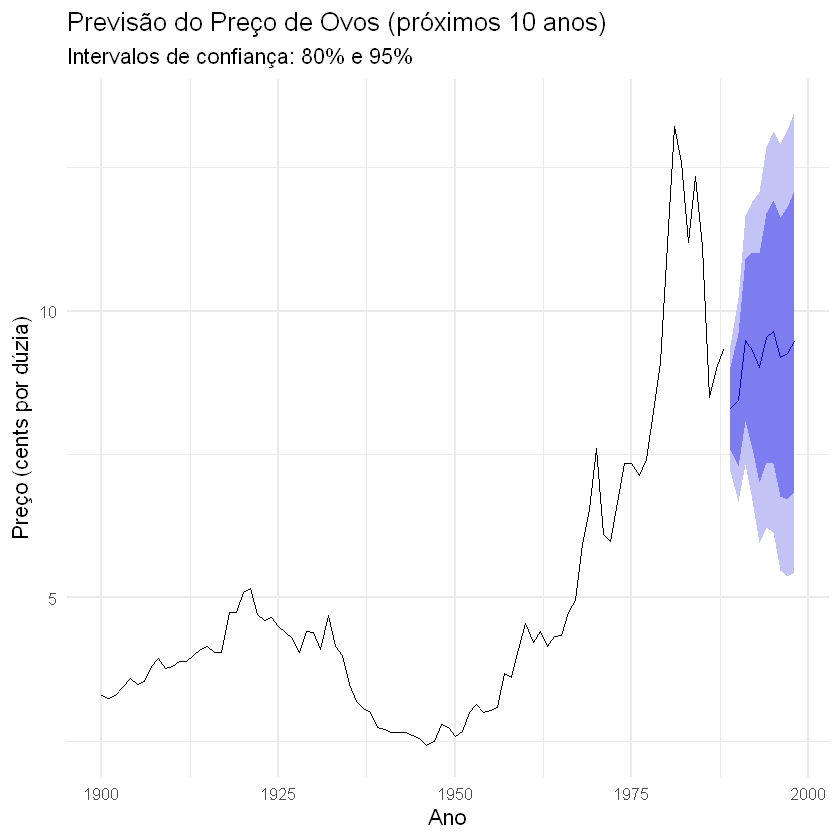

In [30]:
h <- 10  # horizonte: 10 anos

prev <- forecast(modelo_final, h = h, level = c(80, 95))

autoplot(prev) +
  labs(
    title    = "Previsão do Preço de Ovos (próximos 10 anos)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Ano",
    y        = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)